In [4]:
%load_ext autoreload
%autoreload 2

In [33]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time

#For plots 
from shapely.geometry import Polygon, Point
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
import matplotlib as mpl
import geopandas as gpd

# from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

# Open data 

In [6]:
#Post process files 
df_labelled = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all_geo_split_lowest.gpkg')
df_llm = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct_geo.gpkg')

In [7]:
# Case study : 
appeal_cs = "MDRUG050" # "MDRSD034"
df_labelled_geo_cs = df_labelled.loc[df_labelled.appealCode==appeal_cs]
df_llm_geo_cs = df_llm.loc[df_llm.appealCode==appeal_cs]

In [8]:
# Define groups
human_impacts = [
    "Affected People", "Injured People", "Displaced People", "Homeless People",
    "Missing People", "Human Deaths", "Human Health and Wellbeing",
    "Infected and Ill People", "Other Human Impacts"
]

infra_impacts = [
    "Road Infrastructure", "Other Transportation Infrastructure",
    "Water, Sanitation, and Hygiene Infrastructure", "Healthcare Infrastructure",
    "IT and Communication Infrastructure", "Residential Buildings",
    "Informal settlements", "Education Infrastructure",
    "Power and Energy Production Infrastructure", "Agriculture Infrastructure",
    "Other Infrastructure Impacts"
]

service_impacts = [
    "Crop Production and Forestry", "Affected Livestock and Animals",
    "Other Agricultural Impacts", "Recreation, Tourism, and Culture",
    "Other Economic and Livelihood Impacts", "Access to Healthcare",
    "Access to Water, Sanitation, and Hygiene", "Access to transport and Mobility",
    "Water Quality and Availability", "Access to Education",
    "Access to Power and Energy", "Access to Food", "Other Service Access Impacts"
]

all_impacts = human_impacts + infra_impacts + service_impacts

# --- Custom palettes ---
human_palette = [
    "#FFF7BC",  # very light yellow
    "#FEE391",  # pale yellow
    "#FEC44F",  # warm golden
    "#FE9929",  # orange
    "#EC7014",  # orange-red
    "#CC4C02",  # strong red-orange
    "#993404",  # dark reddish brown
    "#D95F0E",  # bright orange-red
    "#E6550D"   # deep orange
]
human_palette_mean = "#993404" #"#F3A649"

infra_palette = [
    "#F7FBFF",  # very light blue
    "#DEEBF7",  # pale blue
    "#C6DBEF",  # sky blue
    "#9ECAE1",  # mid blue
    "#6BAED6",  # strong blue
    "#3182BD",  # bold blue
    "#08519C",  # navy blue
    "#6A51A3",  # indigo
    "#54278F",  # deep purple
    "#3F007D"   # very dark purple
]
infra_palette_mean = "#08519C"

service_palette = [
    "#f5fdc6",  # pale green-yellow
    "#f5c396",  # sandy beige
    "#d0b17a",  # muted brownish yellow
    "#b38a58",  # warm tan
    "#a89f68",  # olive
    "#6f732f",  # olive green
    "#41521f",  # forest green
    "#3c5233",  # dark olive green
    "#264027",  # deep green
    "#0d1f22"   # almost black green
]
service_palette_mean = "#3c5233"

In [25]:
# --- Helper: map subtype -> color ---
subtype_color_map = {}

# Assign first color of each palette to each subtype
for i, s in enumerate(human_impacts):
    subtype_color_map[s] = human_palette[i % len(human_palette)]

for i, s in enumerate(infra_impacts):
    subtype_color_map[s] = infra_palette[i % len(infra_palette)]

for i, s in enumerate(service_impacts):
    subtype_color_map[s] = service_palette[i % len(service_palette)]

In [9]:
# Assign colors to impacts
def assign_custom_colors(subtypes, palette):
    return {sub: palette[i % len(palette)] for i, sub in enumerate(subtypes)}

impact_color_map = {}
impact_color_map.update(assign_custom_colors(human_impacts, human_palette))
impact_color_map.update(assign_custom_colors(infra_impacts, infra_palette))
impact_color_map.update(assign_custom_colors(service_impacts, service_palette))

In [11]:
# Add colors 
gdf_labelled = df_labelled_geo_cs.copy()
gdf_llm = df_llm_geo_cs.copy()

# Unique admin levels
admin_types = gdf_labelled["locationLowestAdmin"].unique()

# Assign colors
gdf_labelled["impactColor"] = gdf_labelled["impactSubtype"].map(impact_color_map)
gdf_llm["impactColor"] = gdf_llm["impactSubtype"].map(impact_color_map)

df_labelled["impactColor"] = df_labelled["impactSubtype"].map(impact_color_map)
df_llm["impactColor"] = df_llm["impactSubtype"].map(impact_color_map)

# Bar plot number of quantitative impact 

In [19]:
# Build category → color map from palettes
impact_color_map_ordered = dict(
    zip(
        human_impacts + infra_impacts + service_impacts,
        human_palette + infra_palette + service_palette
    )
)

def prepare_counts(df, all_impacts):
    counts = df["impactSubtype"].value_counts().reindex(all_impacts, fill_value=0)
    return pd.DataFrame({
        "impactSubtype": all_impacts,
        "count": counts.values,
        "impactColor": [impact_color_map_ordered.get(i, "#BBBBBB") for i in all_impacts]  # fallback grey
    })

def plot_impact_counts(data, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        data["impactSubtype"],
        data["count"],
        color=data["impactColor"],
        edgecolor="black"
    )

    #Change the xlabels 
    n_human = len(human_impacts)
    n_infra = len(infra_impacts)
    n_service = len(service_impacts)
    boundaries = [0, n_human, n_human + n_infra, n_human + n_infra + n_service]

    ax.set_xticks(np.arange(len(all_impacts)))
    ax.set_xticklabels(all_impacts, rotation=45, ha="right", fontsize=10)

    for b in boundaries[1:-1]:  # skip first=0 and last=end
        ax.axvline(b-0.5, color="black", linestyle="--", linewidth=2)

    for i, label in enumerate(ax.get_xticklabels()):
        if i < n_human:
            label.set_color(human_palette_mean)
        elif i < n_human + n_infra:
            label.set_color(infra_palette_mean)
        else:
            label.set_color(service_palette_mean)

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Number of impacts")
    # ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    plt.show()

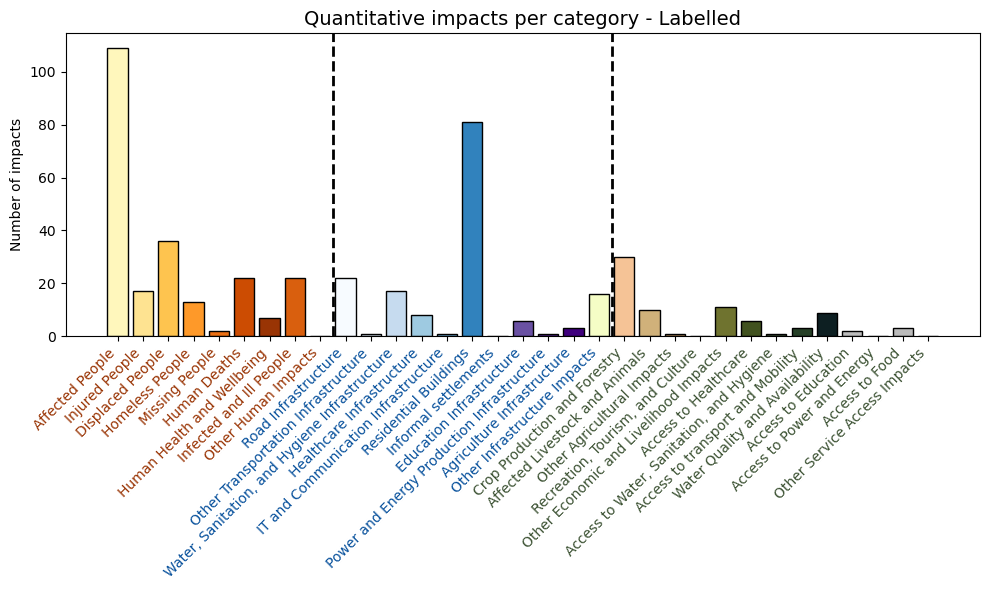

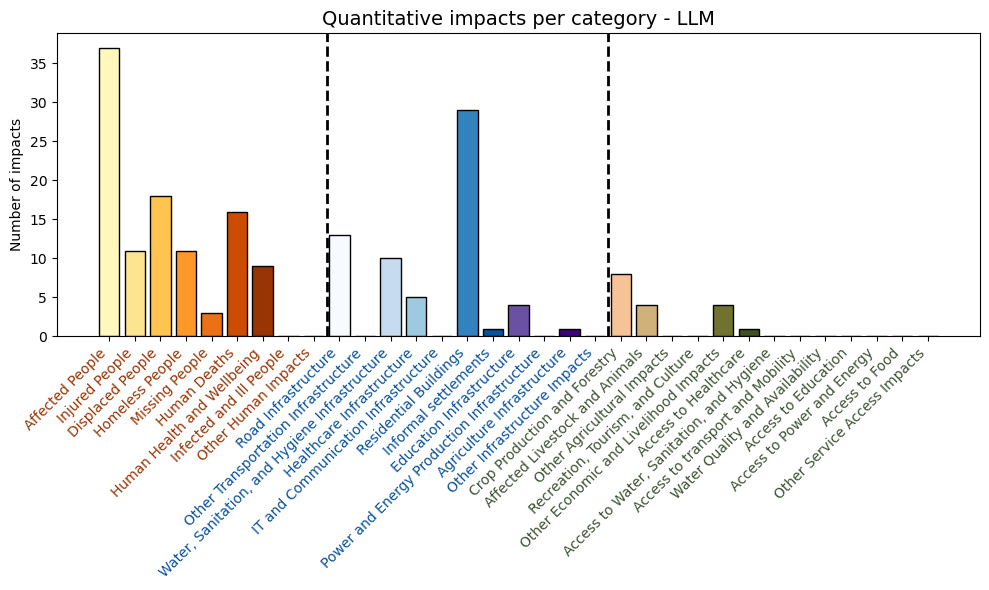

In [20]:
# Prepare counts
df_labelled_quant = df_labelled[df_labelled["impactValuePrecision"].notnull()]
df_llm_quant = df_llm[df_llm["impactValuePrecision"].notnull()]
labelled_quant_counts = prepare_counts(df_labelled_quant, all_impacts)
llm_quant_counts = prepare_counts(df_llm_quant, all_impacts)

# Plots
plot_impact_counts(labelled_quant_counts, "Quantitative impacts per category - Labelled")
plot_impact_counts(llm_quant_counts, "Quantitative impacts per category - LLM")

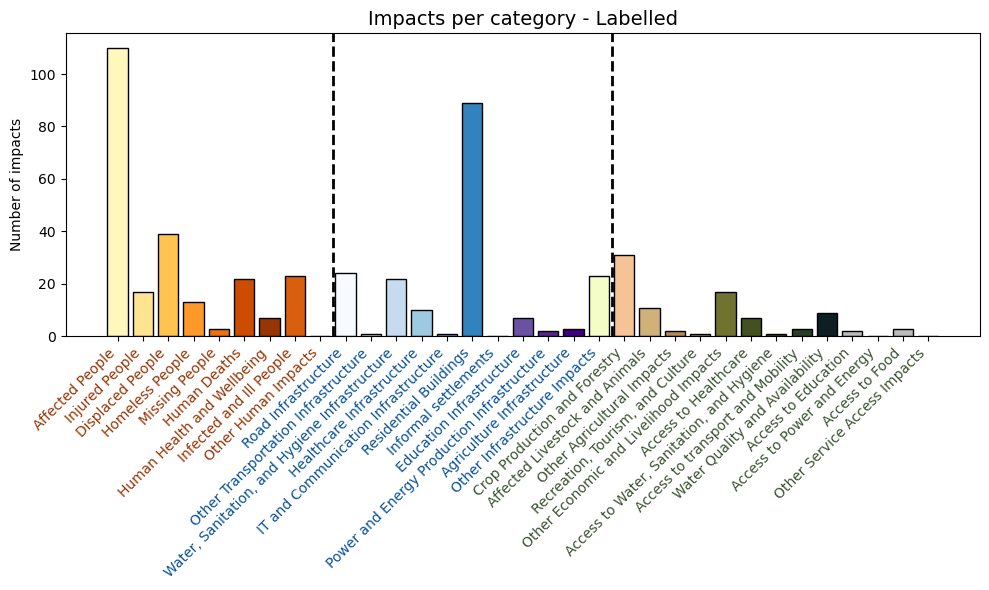

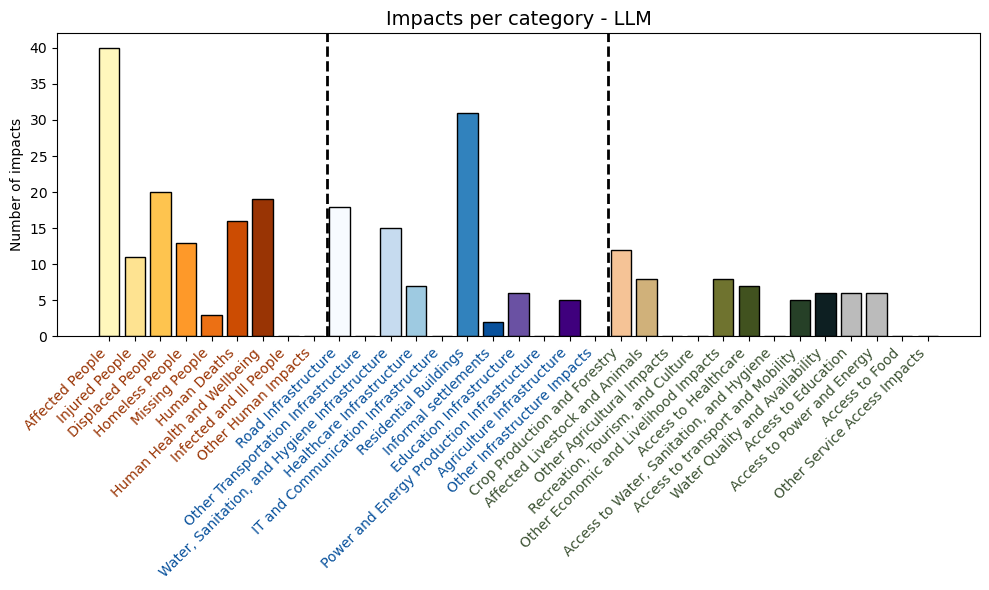

In [21]:
# Prepare counts
labelled_counts = prepare_counts(df_labelled, all_impacts)
llm_counts = prepare_counts(df_llm, all_impacts)

# Plots
plot_impact_counts(labelled_counts, "Impacts per category - Labelled")
plot_impact_counts(llm_counts, "Impacts per category - LLM")

# Plot impact type identified 

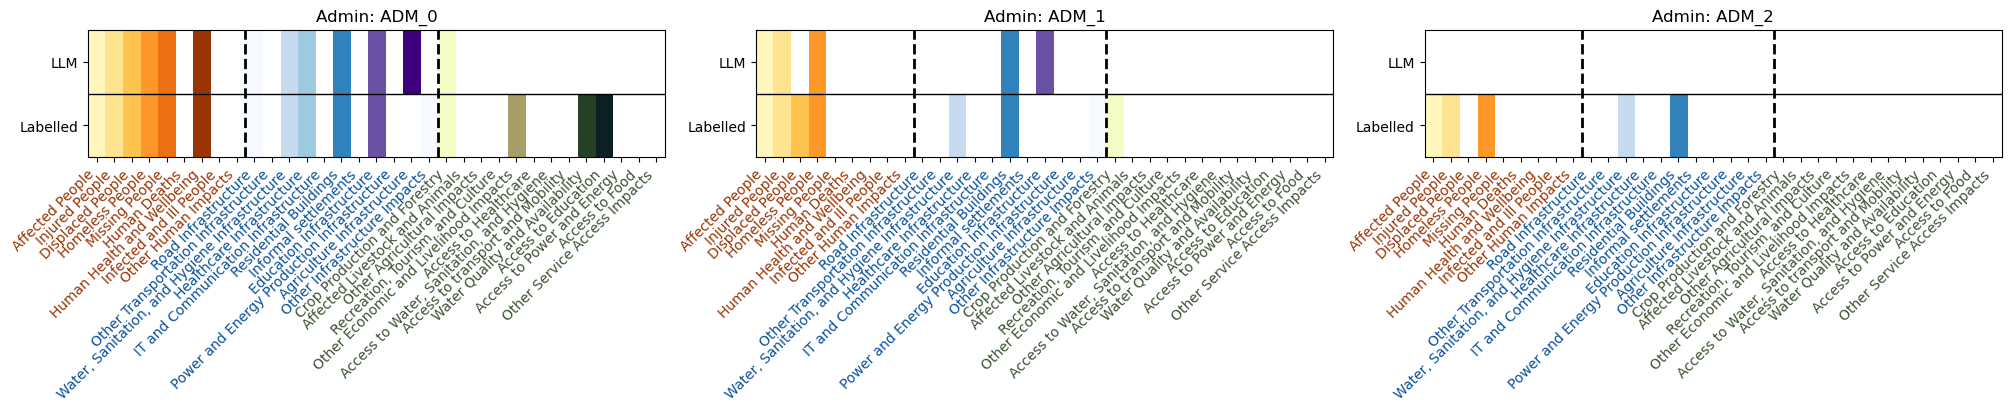

In [125]:
datasets = {
    "Labelled": gdf_labelled,
    "LLM": gdf_llm
}

n_admins = 3

# Create subplot grid (3 columns)
ncols = 3
nrows = (n_admins + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()
n_human = len(human_impacts)
n_infra = len(infra_impacts)
n_service = len(service_impacts)
boundaries = [0, n_human, n_human + n_infra, n_human + n_infra + n_service]

for ax, admin in zip(axes, admin_types):
    for row_idx, (name, df) in enumerate(datasets.items()):
        row_colors = []
        df_sub = df[df["locationLowestAdmin"] == admin]
        for impact in all_impacts:
            if impact in df_sub["impactSubtype"].values:
                color = df_sub.loc[df_sub["impactSubtype"] == impact, "impactColor"].iloc[0]
            else:
                color = "white"
            row_colors.append(mcolors.to_rgba(color))
        ax.imshow([row_colors], aspect="auto", extent=[0, len(all_impacts), row_idx, row_idx+1])

    ax.set_title(f"Admin: {admin}")
    
    #Impact type labels 
    ax.set_xticks(np.arange(len(all_impacts)) + 0.5)
    ax.set_xticklabels(all_impacts, rotation=45, ha="right", fontsize=10)

    ## Optional : Color the xlabels
    for i, label in enumerate(ax.get_xticklabels()):
        if i < n_human:
            label.set_color(human_palette_mean)
        elif i < n_human + n_infra:
            label.set_color(infra_palette_mean)
        else:
            label.set_color(service_palette_mean)


    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(list(datasets.keys()))
    ax.set_xlim(0, len(all_impacts))
    ax.set_ylim(0, len(datasets))

    #Add Boundaries for impact type 
    for b in boundaries[1:-1]:  # skip first=0 and last=end
        ax.axvline(b, color="black", linestyle="--", linewidth=2)

    # # Optional: shaded background per group
    # ax.axvspan(boundaries[0], boundaries[1], facecolor="lightgrey", alpha=0.2)
    # ax.axvspan(boundaries[1], boundaries[2], facecolor="lightblue", alpha=0.2)
    # ax.axvspan(boundaries[2], boundaries[3], facecolor="lightgreen", alpha=0.2)

    #Horizontal line between the 2 datasets
    ax.axhline(1, color="black", linewidth=1)

# Remove extra axes if any
for i in range(len(admin_types), len(axes)):
    fig.delaxes(axes[i])

plt.show()

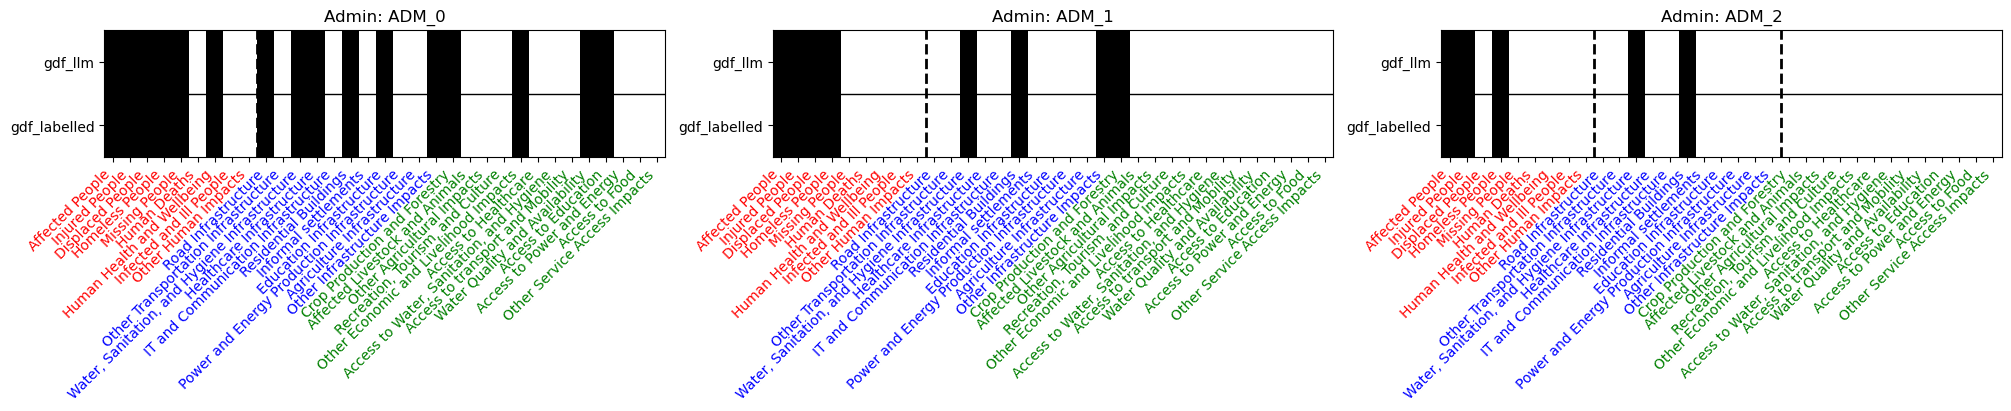

In [97]:
datasets = {
    "gdf_labelled": gdf_labelled,
    "gdf_llm": gdf_llm
}

n_admins = 3

# Create subplot grid (3 columns)
ncols = 3
nrows = (n_admins + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()
n_human = len(human_impacts)
n_infra = len(infra_impacts)
n_service = len(service_impacts)
boundaries = [0, n_human, n_human + n_infra, n_human + n_infra + n_service]

for ax, admin in zip(axes, admin_types):
    for row_idx, (name, df) in enumerate(datasets.items()):
        row_colors = []
        df_sub = df[df["locationLowestAdmin"] == admin]
        for impact in all_impacts:
            if impact in df_sub["impactSubtype"].values:
                color = "black"#df_sub.loc[df_sub["impactSubtype"] == impact, "impactColor"].iloc[0]
            else:
                color = "white"
            row_colors.append(mcolors.to_rgba(color))
        ax.imshow([row_colors], aspect="auto", extent=[0, len(all_impacts), row_idx, row_idx+1])

    ax.set_title(f"Admin: {admin}")
    
    #Impact type labels 
    ax.set_xticks(np.arange(len(all_impacts)) + 0.5)
    ax.set_xticklabels(all_impacts, rotation=45, ha="right", fontsize=10)

    ## Optional : Color the xlabels
    for i, label in enumerate(ax.get_xticklabels()):
        if i < n_human:
            label.set_color("red")
        elif i < n_human + n_infra:
            label.set_color("blue")
        else:
            label.set_color("green")


    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(list(datasets.keys()))
    ax.set_xlim(0, len(all_impacts))
    ax.set_ylim(0, len(datasets))

    #Add Boundaries for impact type 
    for b in boundaries[1:-1]:  # skip first=0 and last=end
        ax.axvline(b, color="black", linestyle="--", linewidth=2)

    # # Optional: shaded background per group
    # ax.axvspan(boundaries[0], boundaries[1], facecolor="lightgrey", alpha=0.2)
    # ax.axvspan(boundaries[1], boundaries[2], facecolor="lightblue", alpha=0.2)
    # ax.axvspan(boundaries[2], boundaries[3], facecolor="lightgreen", alpha=0.2)

    #Horizontal line between the 2 datasets
    ax.axhline(1, color="black", linewidth=1)

# Remove extra axes if any
for i in range(len(admin_types), len(axes)):
    fig.delaxes(axes[i])

plt.show()

# Plots of impact magnitude for given impact types

Use the same colors are the one defining the impact categories

In [12]:
def plot_subtypes_appeal(appeal_df, subtype, axes, cmap, norm):
    df_subtype = appeal_df[appeal_df["impactSubtype"] == subtype]
    df_subtype = df_subtype.sort_values("impactValue", ascending=False)
    nrows_subtype = len(df_subtype)
    for irow in range(nrows_subtype):
        row = df_subtype.iloc[[irow]]
        alpha = 0.1 + irow/(1.1*nrows_subtype)
        row.set_geometry("geometry").plot(
            ax=axes,
            column="impactValue",
            cmap=cmap,
            norm=norm,
            alpha=alpha,
            legend=False,
        )
    return axes

In [31]:
def make_gradient_cmap(base_color, n_colors=256):
    """Create a sequential colormap from white → base_color."""
    return LinearSegmentedColormap.from_list("custom_cmap", ["#ffffff", base_color], N=n_colors)


In [17]:
df_llm.head(3)

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,gaul0_code,gaul1_code,gaul2_code,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul,geometry,impactColor
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,['Pakistan'],"['Balochistan', 'Khyber Pakhtunkhwa (KP)', 'Si...",['The monsoon season caused306 fatalities and5...,...,[260.0],"[2905, None, 2909, 2908]",[None],ADM_0,3,0,"['Balochistan', 'Pakistan', 'Sindh', 'Punjab']","['Balochistan', 'Pakistan', 'Sindh', 'Punjab']","MULTIPOLYGON (((67.45802 24.06273, 67.47779 24...",#CC4C02
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,['Pakistan'],"['Balochistan', 'Khyber Pakhtunkhwa (KP)', 'Si...",['The monsoon season caused306 fatalities and5...,...,[260],"[2905, 2907, 2909, 2908]","[None, 130162]",ADM_1,0,1,"['Balochistan', 'Musa khan kallay', 'Sindh', '...","['Balochistan', 'Swabi', 'Sindh', 'Punjab']","MULTIPOLYGON (((67.11349 24.6854, 67.11579 24....",#FEE391
2,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",['Pakistan'],"['Sindh', 'Badin', 'Dadu', 'Jacobabad']","['Sindh experienced acute urban flooding, part...",...,[260],[2909],"[None, 130203, 130205, 130209]",ADM_1,0,0,"['Sindh', 'Badin', 'Dadu', 'Jacobabad']","['Sindh', 'Badin', 'Dadu', 'Jacobabad']","MULTIPOLYGON (((67.29894 24.55476, 67.30287 24...",#FEC44F


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_37004\1240762555.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


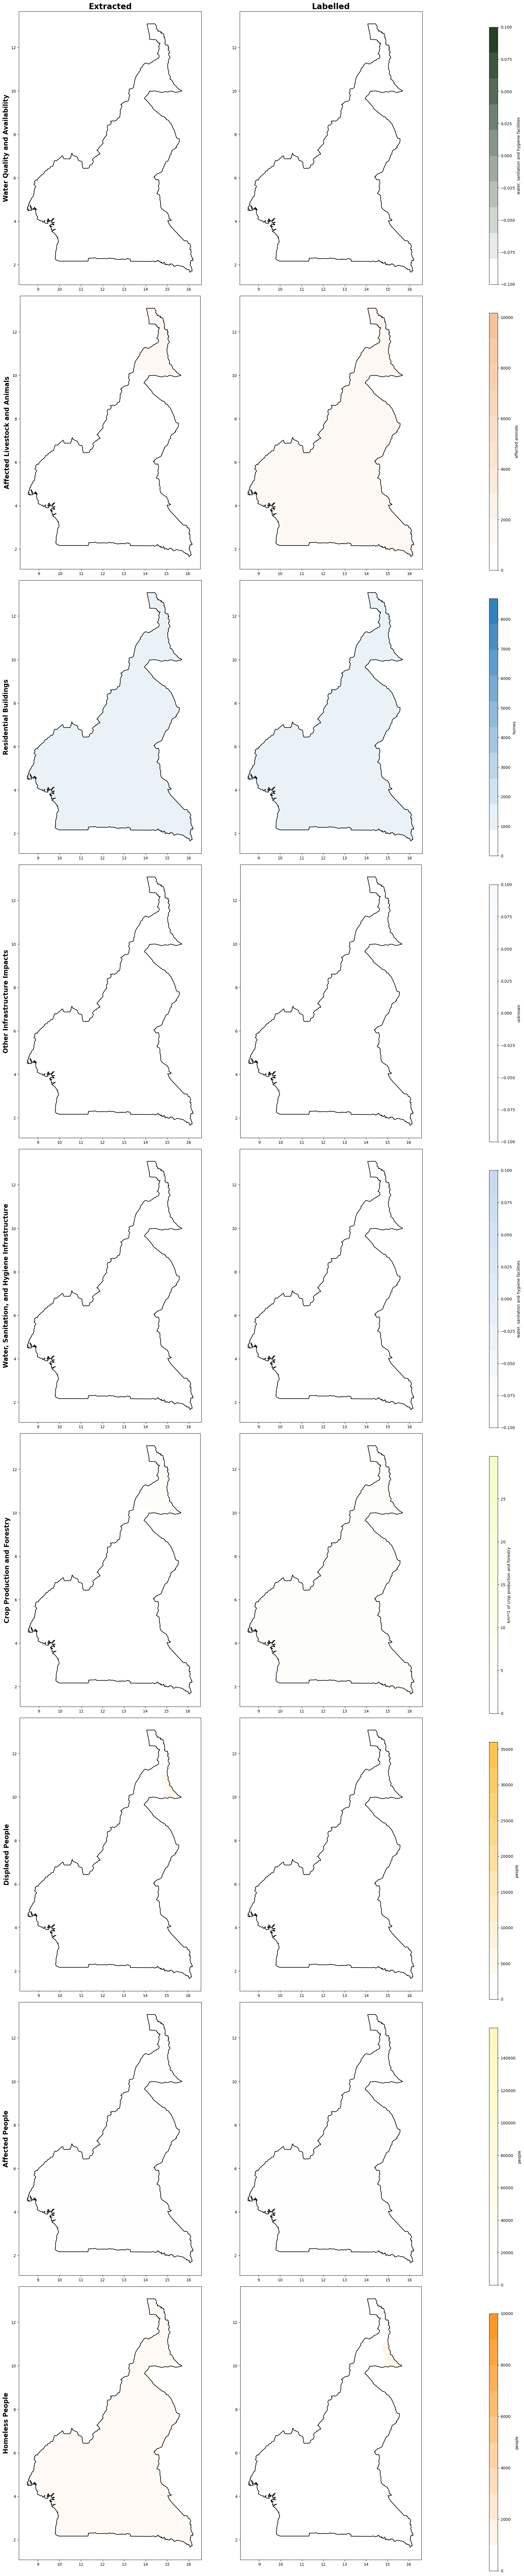

In [39]:
# Data filtering
appeal_plot = "MDRCM039" #"MDRCM039"
extracted_df_appeal = df_llm_quant[df_llm_quant["appealCode"] == appeal_plot]
labelled_df_appeal = df_labelled_quant[df_labelled_quant["appealCode"] == appeal_plot]
ctry_shape = gpd.GeoDataFrame(df_llm[(df_llm["appealCode"] == appeal_plot) &
                          (df_llm["locationLowestAdmin"] == "ADM_0")]).set_geometry("geometry").iloc[[0]]
subtypes_all = set(extracted_df_appeal["impactSubtype"].unique()) | set(labelled_df_appeal["impactSubtype"].unique())
#impact_subtypes_desc_dict.keys()#["Affected People", "Human Deaths", "Residential Buildings", "Education Infrastructure"]
nrows = len(subtypes_all)
ncols = 2

# Setup figure
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10*nrows), squeeze=False)
# cmap = "Reds"

    # # Discrete colorbar (just a swatch)
    # cbar_ax = fig.add_axes([0.92, 1 - (isub + 1) / nrows, 0.015, 1 / nrows * 0.9])
    # cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm,
    #                                boundaries=[0, 1], ticks=[], spacing='proportional')
    # cb.set_label(f"{unit}")

    # axes[isub, 0].set_ylabel(subtype, fontsize=16, fontweight="bold")

for isub, subtype in enumerate(subtypes_all):
    ext_df_subtype = extracted_df_appeal[extracted_df_appeal["impactSubtype"] == subtype]
    lab_df_subtype = labelled_df_appeal[labelled_df_appeal["impactSubtype"] == subtype]

    # Skip if both are empty
    if ext_df_subtype.empty and lab_df_subtype.empty:
        continue

    #first plot country shape
    ctry_shape.boundary.plot(ax=axes[isub, 0], color="k")
    ctry_shape.boundary.plot(ax=axes[isub, 1], color="k")

    unit = ext_df_subtype["impactUnit"].value_counts().index[0] if not ext_df_subtype.empty else lab_df_subtype["impactUnit"].value_counts().index[0]

    # Shared color scaling for this row
    vmin = 0
    # min(
    #     ext_df_subtype["impactValue"].min(skipna=True) if not ext_df_subtype.empty else float("inf"),
    #     lab_df_subtype["impactValue"].min(skipna=True) if not lab_df_subtype.empty else float("inf")
    # )
    vmax = max(
        ext_df_subtype["impactValue"].max(skipna=True) if not ext_df_subtype.empty else float("-inf"),
        lab_df_subtype["impactValue"].max(skipna=True) if not lab_df_subtype.empty else float("-inf")
    )
    # norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # Pick base color for this subtype
    base_color = subtype_color_map.get(subtype, "#cccccc")

    # Build gradient cmap from white → base_color
    cmap = make_gradient_cmap(base_color, 10)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # Plot Extracted & Labelled
    plot_subtypes_appeal(ext_df_subtype, subtype, axes[isub, 0], cmap, norm)
    plot_subtypes_appeal(lab_df_subtype, subtype, axes[isub, 1], cmap, norm)

    # # Add colorbar for this row
    # cbar_ax = fig.add_axes([0.92, 1 - (isub + 1) / nrows, 0.015, 1 / nrows * 0.9])
    # fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax).set_label(f"{unit}")

    # # Labels
    # axes[isub, 0].set_ylabel(subtype, fontsize=16, fontweight="bold")
    # Colorbar (continuous gradient)
    cbar_ax = fig.add_axes([0.92, 1 - (isub + 1) / nrows, 0.015, 1 / nrows * 0.9])
    cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm)
    cb.set_label(f"{unit}")

    axes[isub, 0].set_ylabel(subtype, fontsize=16, fontweight="bold")

axes[0, 0].set_title("Extracted", fontsize=20, fontweight="bold")
axes[0, 1].set_title("Labelled", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Plots maps with impact types 

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\1963749265.py:84: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.5)


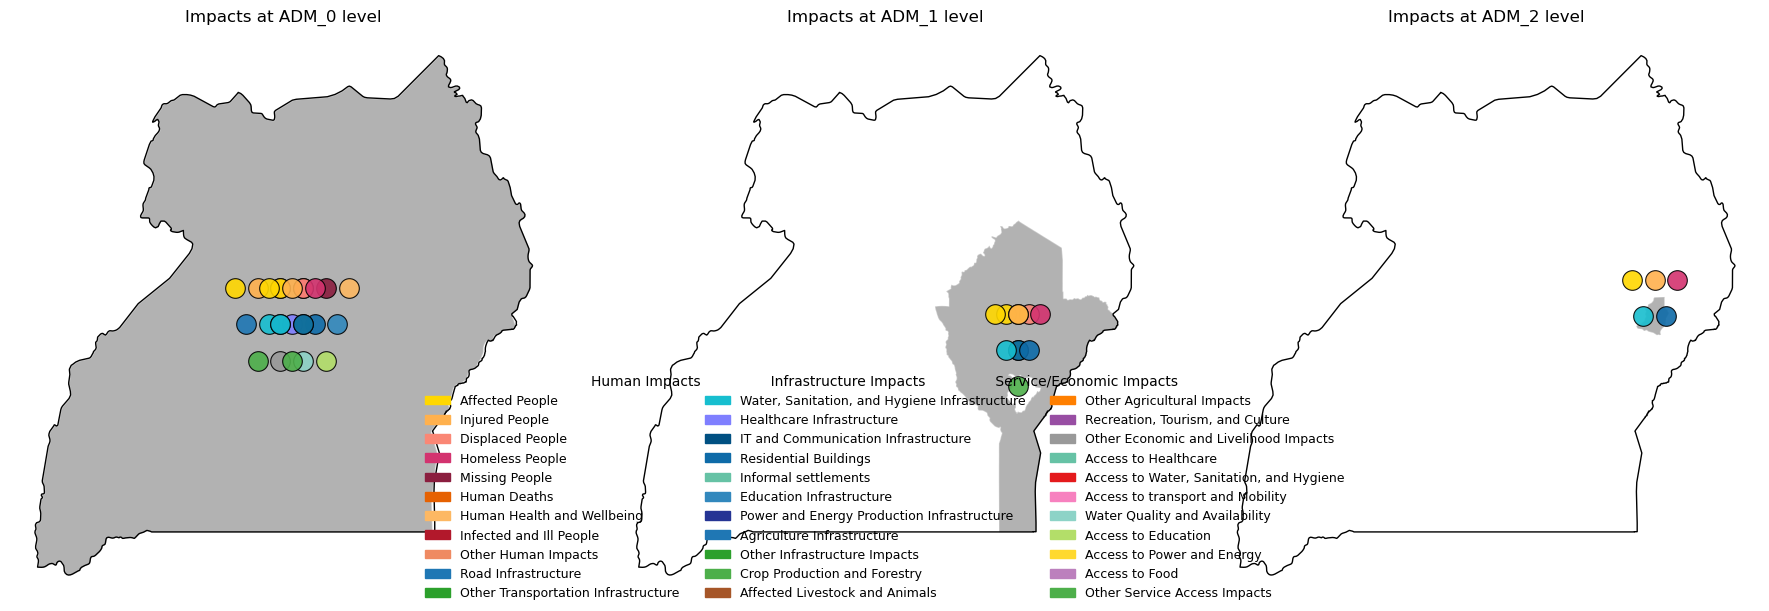

In [60]:
# Unique admin levels
admin_types = gdf["locationLowestAdmin"].unique()

# Setup subplots
fig, axes = plt.subplots(
    1, len(admin_types), figsize=(6*len(admin_types), 6), constrained_layout=True
)

if len(admin_types) == 1:
    axes = [axes]

for ax, admin in zip(axes, admin_types):
    subset = gdf[gdf["locationLowestAdmin"] == admin]

    if subset.empty:
        ax.set_title(f"Impacts at {admin} level")
        ax.axis("off")
        continue

    # Plot full country outline
    country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

    # Shade impacted regions once
    subset.dissolve().plot(ax=ax, color="black", alpha=0.3, edgecolor="white")

    # Group by geometry
    for geom, group in subset.groupby(subset.geometry):
        centroid = geom.centroid

        # Keep unique impact types
        group_unique = group.drop_duplicates(subset="impactSubtype")

        # Organize by family
        families = {
            "Human": [s for s in group_unique["impactSubtype"] if s in human_impacts],
            "Infrastructure": [s for s in group_unique["impactSubtype"] if s in infra_impacts],
            "Service": [s for s in group_unique["impactSubtype"] if s in service_impacts],
        }

        # Plot each family in one row
        family_offsets = {"Human": 0.4, "Infrastructure": 0, "Service": -0.4}
        spacing = 0.25  # horizontal distance between dots

        for family, impacts in families.items():
            impacts_sorted = sorted(
                impacts, key=lambda x: list(impact_color_map.keys()).index(x)
            )
            for i, subtype in enumerate(impacts_sorted):
                color = impact_color_map[subtype]
                x = centroid.x + i * spacing - (len(impacts_sorted)-1) * spacing / 2
                y = centroid.y + family_offsets[family]
                ax.scatter(
                    x, y,
                    color=color,
                    s=200, edgecolor="black", linewidth=0.8, alpha=0.9
                )

    ax.set_title(f"Impacts at {admin} level")
    ax.axis("off")

# ===== Legend (3 columns, separated by family) =====
legend_elements = []

# Human
human_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in human_impacts]
# Infrastructure
infra_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in infra_impacts]
# Service
service_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in service_impacts]

# Build combined legend
from matplotlib.legend import Legend

fig.legend(
    handles=human_patches + infra_patches + service_patches,
    labels=[p.get_label() for p in human_patches + infra_patches + service_patches],
    loc="lower center",
    ncol=3,
    fontsize=9,
    frameon=False,
    title="Human Impacts                Infrastructure Impacts                Service/Economic Impacts"
)

plt.subplots_adjust(bottom=0.5)
plt.show()


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\1696676205.py:105: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.5)


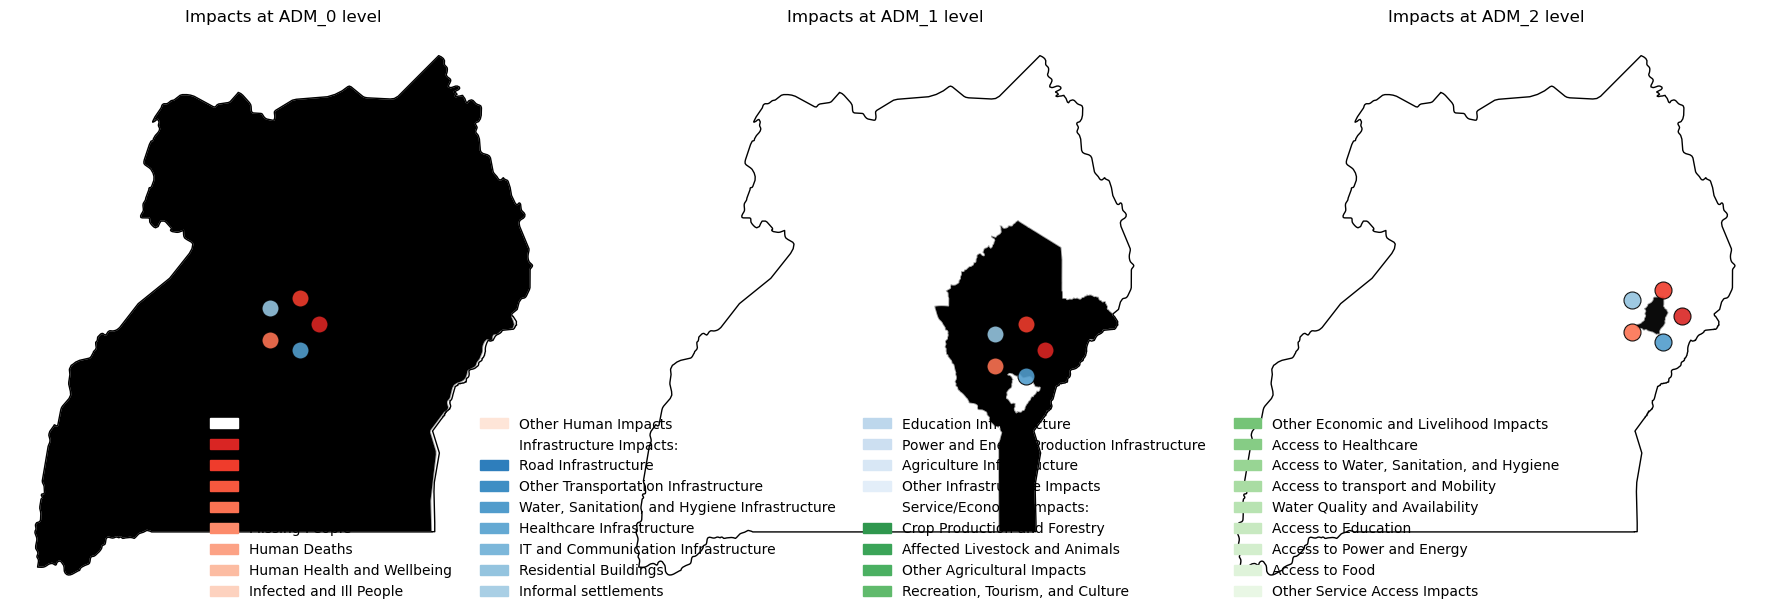

In [ ]:
# Unique admin levels
admin_types = gdf["locationLowestAdmin"].unique()

# Setup subplots
fig, axes = plt.subplots(
    1, len(admin_types), figsize=(6*len(admin_types), 6), constrained_layout=True
)

if len(admin_types) == 1:
    axes = [axes]

for ax, admin in zip(axes, admin_types):
    subset = gdf[gdf["locationLowestAdmin"] == admin]

    # Plot full country outline
    country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

    # Shade impacted regions
    subset.plot(ax=ax, color="black", alpha=0.4, edgecolor="white")

    #Plot centroid to show the impact types 
    for geom, group in subset.groupby(subset.geometry):
        centroid = geom.centroid
        # Keep only one row per impactSubtype
        group_unique = group.drop_duplicates(subset="impactSubtype")
        n = len(group_unique)

        if n == 1:
            # Single dot at centroid
            row = group.iloc[0]
            ax.scatter(
                centroid.x, centroid.y,
                color=row["impactColor"],
                s=150, edgecolor="black", linewidth=0.5, alpha=0.9
            )
    else:
        # Parameters
        base_radius = 0.3   # bigger spread
        dots_per_ring = 8   # max per circle
        ring_spacing = 0.08 # spacing between concentric rings

        rings = int(np.ceil(n / dots_per_ring))

        idx = 0
        for r in range(rings):
            radius = base_radius + r * ring_spacing
            k = min(dots_per_ring, n - idx)
            angles = np.linspace(0, 2*np.pi, k, endpoint=False)

            for i in range(k):
                row = group_unique.iloc[idx]
                x = centroid.x + radius * np.cos(angles[i])
                y = centroid.y + radius * np.sin(angles[i])
                ax.scatter(
                    x, y,
                    color=row["impactColor"],
                    s=150, edgecolor="black", linewidth=0.8, alpha=0.9
                )
                idx += 1

    ax.set_title(f"Impacts at {admin} level")
    ax.axis("off")

# ===== Legend (Grouped) =====
# ===== Build full legend grouped by category =====
legend_elements = []

# Human impacts
legend_elements.append(mpatches.Patch(color='white', label='Human Impacts:'))  # group title
for subtype in human_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Infrastructure impacts
legend_elements.append(mpatches.Patch(color='white', label='Infrastructure Impacts:'))
for subtype in infra_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Service/Economic impacts
legend_elements.append(mpatches.Patch(color='white', label='Service/Economic Impacts:'))
for subtype in service_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Add legend under all subplots
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,          # adjust for better layout
    fontsize=10,
    frameon=False
)

plt.subplots_adjust(bottom=0.5)
plt.show()


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


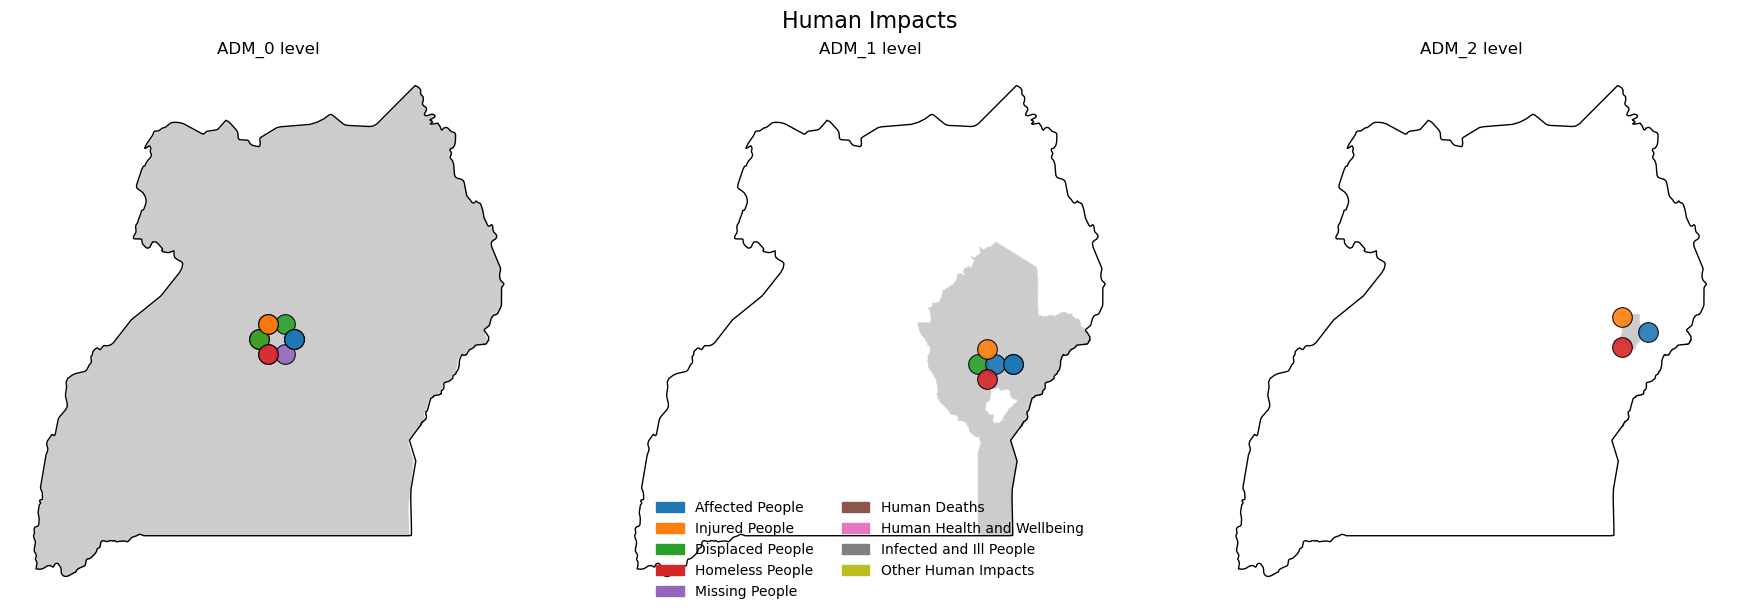

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


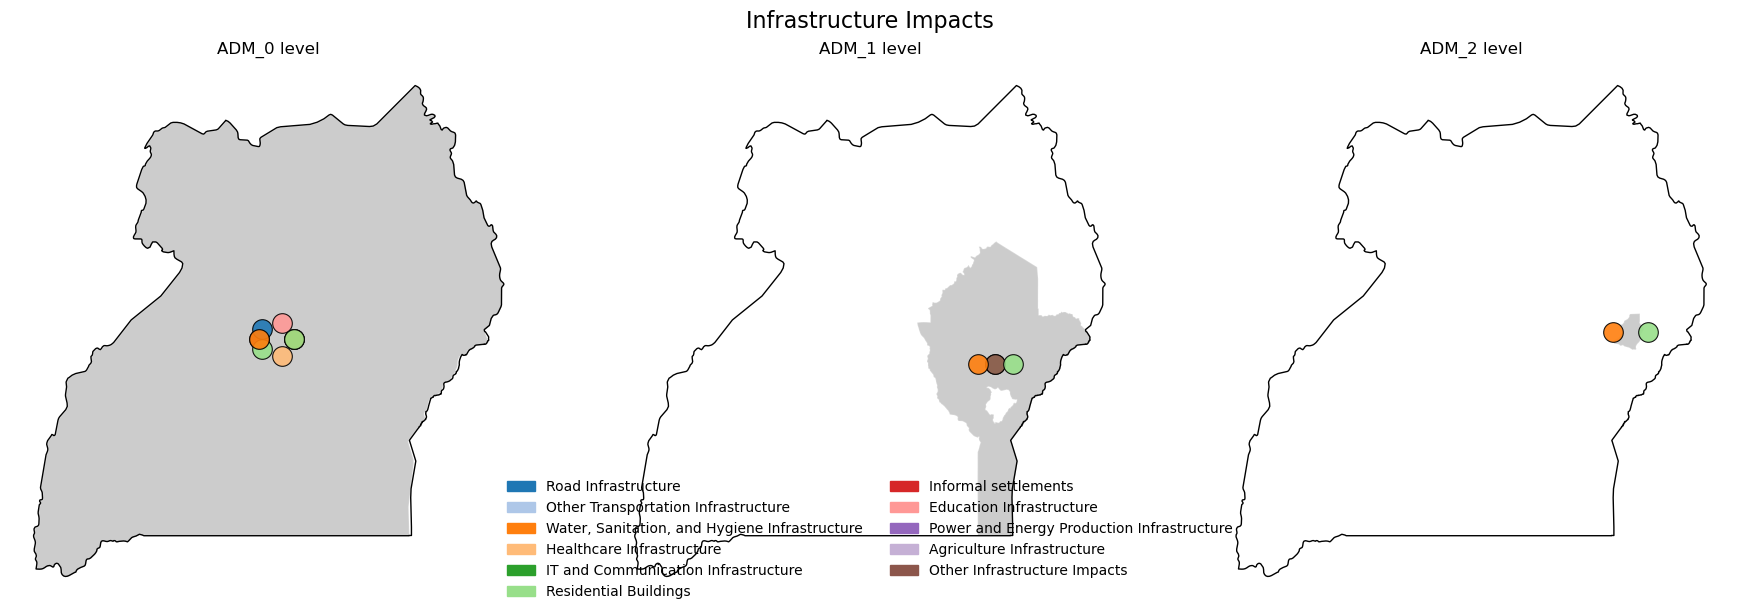

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


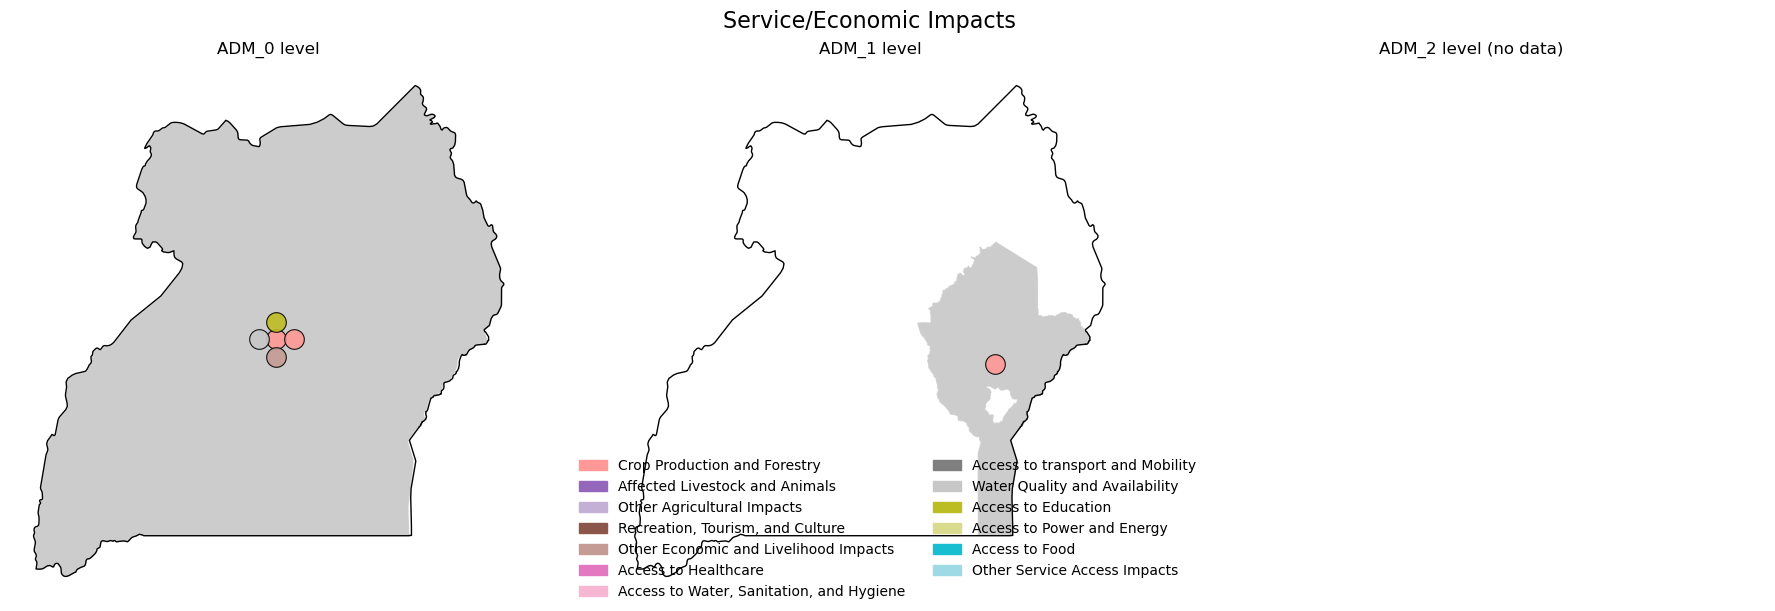

In [52]:
# Country boundary (background global picture)
country_outline = gdf.dissolve(by="country")

admin_types = gdf["locationLowestAdmin"].unique()
n_admin = len(admin_types)

families = {
    "Human": human_impacts,
    "Infrastructure": infra_impacts,
    "Service/Economic": service_impacts
}

for family_name, subtypes in families.items():
    fig, axes = plt.subplots(1, n_admin, figsize=(6*n_admin,6), constrained_layout=True)
    if n_admin == 1:
        axes = [axes]

    # Subset data for this family
    family_subset = gdf[gdf["impactSubtype"].isin(subtypes)]
    impacted_regions = family_subset.dissolve(by="locationLowestAdmin")

    for ax, admin in zip(axes, admin_types):
        subset = family_subset[family_subset["locationLowestAdmin"] == admin]

        if subset.empty:
            # Leave subplot empty
            ax.set_title(f"{admin} level (no data)")
            ax.axis("off")
            continue

        # Plot full country outline
        country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

        # Shade impacted regions only once
        if admin in impacted_regions.index:
            impacted_regions.loc[[admin]].plot(
                ax=ax, color="black", alpha=0.2, edgecolor="white"
            )

        subset = family_subset[(family_subset["locationLowestAdmin"] == admin)]

        # Plot centroids (organized with concentric rings)
        for geom, group in subset.groupby(subset.geometry):
            centroid = geom.centroid
            group_unique = group.drop_duplicates(subset="impactSubtype")
            n = len(group_unique)

            if n == 1:
                row = group_unique.iloc[0]
                ax.scatter(
                    centroid.x, centroid.y,
                    color=row["impactColor"], s=200,
                    edgecolor="black", linewidth=0.8, alpha=0.9
                )
            else:
                # Concentric rings layout
                base_radius = 0.2
                dots_per_ring = 8
                ring_spacing = 0.1
                rings = int(np.ceil(n / dots_per_ring))
                idx = 0
                for r in range(rings):
                    radius = base_radius + r * ring_spacing
                    k = min(dots_per_ring, n - idx)
                    angles = np.linspace(0, 2*np.pi, k, endpoint=False)
                    for i in range(k):
                        row = group_unique.iloc[idx]
                        x = centroid.x + radius*np.cos(angles[i])
                        y = centroid.y + radius*np.sin(angles[i])
                        ax.scatter(
                            x, y,
                            color=row["impactColor"], s=200,
                            edgecolor="black", linewidth=0.8, alpha=0.9
                        )
                        idx += 1

        ax.set_title(f"{admin} level")
        ax.axis("off")

    # Legend for this family
    family_legend = [mpatches.Patch(color=impact_color_map[sub], label=sub) for sub in subtypes]
    fig.legend(handles=family_legend, loc="lower center", ncol=2, fontsize=10, frameon=False)
    plt.subplots_adjust(bottom=0.25)
    fig.suptitle(f"{family_name} Impacts", fontsize=16)
    plt.show()
